In [1]:
include("dependencies.jl")
import Pkg;
Pkg.add("LsqFit")
using LsqFit, Plots

Precompiling project...
   4166.8 ms  ✓ LsqFit
  1 dependency successfully precompiled in 14 seconds. 508 already precompiled.
   Resolving package versions...
  No Changes to `C:\Users\14aka\.julia\environments\v1.11\Project.toml`
  No Changes to `C:\Users\14aka\.julia\environments\v1.11\Manifest.toml`


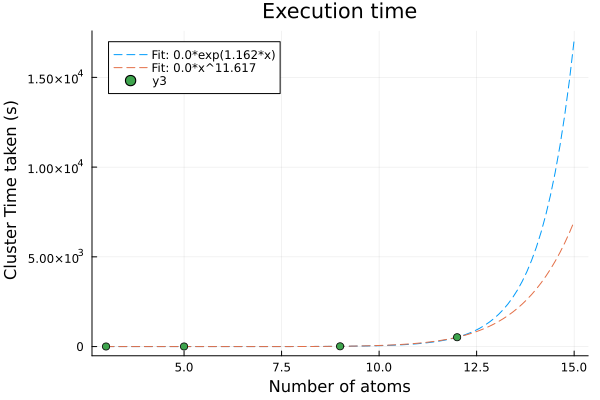

In [12]:
sys_size = [3,5,9,12]
cluster_time_taken = [5.8, 6.3, 15.8, 522.0]

exponential(x, p) = p[1] .* exp.(p[2] .* x)
power_law(x, p) = p[1] .* x .^ p[2]
p0_exp = [1.0, 0.1]
p0_power = [1.0, 1.0]

exp_fit = curve_fit(exponential, sys_size, cluster_time_taken, p0_exp)
power_fit = curve_fit(power_law, sys_size, cluster_time_taken, p0_power)

a1 = trunc(exp_fit.param[1],digits=3)
b1 = trunc(exp_fit.param[2],digits=3)

a2 = trunc(power_fit.param[1],digits=5)
b2 = trunc(power_fit.param[2],digits=3)

x_vals = range(minimum(sys_size), 15, length=100)

fitted_y1_vals = exponential(x_vals, exp_fit.param)
fitted_y2_vals = power_law(x_vals, power_fit.param)

plot(x_vals, fitted_y1_vals, linestyle=:dash, label="Fit: $(a1)*exp($(b1)*x)")
plot!(x_vals, fitted_y2_vals, linestyle=:dash, label="Fit: $(a2)*x^$(b2)")
scatter!(sys_size, cluster_time_taken, xlabel="Number of atoms", ylabel=" Cluster Time taken (s)", title="Execution time")

In [15]:
println("According to power law, the time taken for 15 atom MCWF simulation of a single trajectory is $(fitted_y2_vals[end]) seconds")
println("According to exponential law, the time taken for 15 atom MCWF simulation of a single trajectory is $(fitted_y1_vals[end]) seconds")

According to power law, the time taken for 15 atom MCWF simulation of a single trajectory is 6973.235461318566 seconds
According to exponential law, the time taken for 15 atom MCWF simulation of a single trajectory is 17079.952162580055 seconds


In [17]:
6973/60/60

1.9369444444444446

In [18]:
17080/60/60

4.7444444444444445